# SparK: A Visualization Demo
A demo using our pretrained SparK model to reconstruct masked images.
The mask is whether specified by the user or randomly generated.

**NOTE:** if you want to visualize your own pretrained model, you may need to modify the `IMAGENET_RGB_MEAN` and `IMAGENET_RGB_STD` below to your numbers. In Step 5, use `spark, input_size = build_spark('_withdecoder_1kpretrained_spark_style.pth')` to load your model.

## 1. Preparation
Install dependencies, specify the device, and specify the pretrained model.

In [1]:
import sys
import torch

TARGET_GPU_ID = 6

if torch.cuda.is_available() and torch.cuda.device_count() > TARGET_GPU_ID:
    DEVICE = torch.device(f'cuda:{TARGET_GPU_ID}')
else:
    DEVICE = torch.device('cpu')
    print(f"Warning: GPU {TARGET_GPU_ID} is not available. Falling back to {DEVICE}.")

print(f'[DEVICE={DEVICE}]')

[DEVICE=cuda:6]


## 2. Define utils: load data

In [2]:
from PIL import Image
import torchvision.transforms.functional as TF
IMAGENET_RGB_MEAN = torch.tensor((0.485, 0.456, 0.406), device=DEVICE).reshape(1, 3, 1, 1)
IMAGENET_RGB_STD = torch.tensor((0.229, 0.224, 0.225), device=DEVICE).reshape(1, 3, 1, 1)
def load_image(size: int, img_file: str):
    img = Image.open(img_file).convert('RGB')
    img = TF.center_crop(TF.resize(img, size), [size, size])
    img = TF.to_tensor(img).unsqueeze(0).to(DEVICE).sub(IMAGENET_RGB_MEAN).div_(IMAGENET_RGB_STD)
    return img
def denormalize(img_bchw):
    return img_bchw.mul(IMAGENET_RGB_STD).add_(IMAGENET_RGB_MEAN).clamp_(0., 1.)

## 3. Define utils: build a SparK model

In [3]:
import os
from decoder import LightDecoder
from encoder import SparseEncoder
from models import build_sparse_encoder
from spark import SparK
def build_spark(your_own_pretrained_ckpt: str = '/home/tts26/sonh/logs/hgnetv2_3data_100ep/hgnetv2_b1.ssld_stage1_in22k_in1k_withdecoder.pth'):
    all_state = torch.load(your_own_pretrained_ckpt, map_location='cpu')
    input_size, model_name = all_state['input_size'], all_state['arch']
    pretrained_state = all_state['module']
    print(f"[in function `build_spark`] your ckpt `{your_own_pretrained_ckpt}` loaded;  don't forget to modify IMAGENET_RGB_MEAN and IMAGENET_RGB_MEAN above if needed")

    # build a SparK model
    config = pretrained_state['config']
    enc: SparseEncoder = build_sparse_encoder(model_name, input_size=input_size)
    spark = SparK(
        sparse_encoder=enc, dense_decoder=LightDecoder(enc.downsample_ratio, sbn=False),
        mask_ratio=config['mask_ratio'], densify_norm=config['densify_norm_str'], sbn=config['sbn'],
    ).to(DEVICE)
    spark.eval(), [p.requires_grad_(False) for p in spark.parameters()]
    
    # load the checkpoint
    missing, unexpected = spark.load_state_dict(pretrained_state, strict=False)
    assert len(missing) == 0, f'load_state_dict missing keys: {missing}'
    assert len(unexpected) == 0, f'load_state_dict unexpected keys: {unexpected}'
    del pretrained_state
    return spark, input_size


/home/tts26/miniconda3/envs/spark/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 4. Define utils: visualize

In [4]:
import matplotlib.pyplot as plt
def show(spark: SparK, size: int, img_file='viz_imgs/image-01.png', active_b1ff: torch.BoolTensor = None):
    inp_bchw = load_image(size, img_file)
    spark.forward
    inp_bchw, masked_bchw, rec_or_inp = spark(inp_bchw, active_b1ff=active_b1ff, vis=True)
    # plot these three images in a row
    masked_title = 'rand masked' if active_b1ff is None else 'specified masked'
    for col, (title, bchw) in enumerate(zip(['input', masked_title, 'reconstructed'], [inp_bchw, masked_bchw, rec_or_inp])):
        plt.subplot2grid((1, 3), (0, col))
        plt.imshow(denormalize(bchw)[0].permute(1, 2, 0).cpu().numpy())
        plt.title(title)
        plt.axis('off')
    plt.show()

## 5. Run SparK with a specified mask

In [5]:
spark, input_size = build_spark()

/tmp/ipykernel_2443769/3735242422.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  all_state = torch.load(your_own_pretrained_ckpt, map_location='cpu')


[in function `build_spark`] your ckpt `/home/tts26/sonh/logs/hgnetv2_3data_100ep/hgnetv2_b1.ssld_stage1_in22k_in1k_withdecoder.pth` loaded;  don't forget to modify IMAGENET_RGB_MEAN and IMAGENET_RGB_MEAN above if needed
[SparK.__init__, densify 1/4]: densify_proj(ksz=1, #para=0.79M)
[SparK.__init__, densify 2/4]: densify_proj(ksz=3, #para=1.77M)
[SparK.__init__, densify 3/4]: densify_proj(ksz=3, #para=0.44M)
[SparK.__init__, densify 4/4]: densify_proj(ksz=3, #para=0.06M)
[SparK.__init__] dims of mask_tokens=(1024, 512, 256, 64)


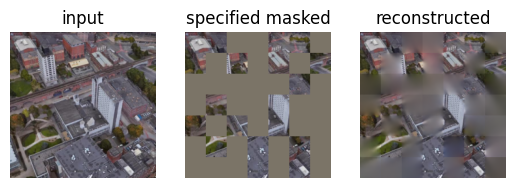

In [6]:
# specify the mask
if input_size == 384:
    active_b1ff = torch.tensor([
        [0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    ], device=DEVICE).bool().reshape(1, 1, 12, 12)
elif input_size == 224:
    active_b1ff = torch.tensor([
        [1, 1, 0, 0, 1, 1, 0],
        [1, 0, 1, 0, 1, 0, 1],
        [0, 0, 0, 0, 0, 1, 0],
        [0, 1, 0, 0, 1, 0, 0],
        [1, 0, 1, 0, 1, 0, 0],
        [0, 1, 0, 1, 0, 1, 0],
        [0, 0, 0, 1, 0, 1, 0],
    ], device=DEVICE).bool().reshape(1, 1, 7, 7)
else:
    raise NotImplementedError('define your mask for other input_size')

show(spark, input_size, 'viz_imgs/image-01.jpeg', active_b1ff=active_b1ff)

## 6. Run SparK with a random mask

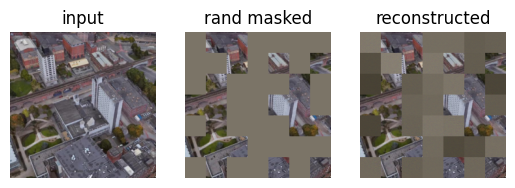

In [8]:
# use a random mask (don't specify the mask)
show(spark, input_size, 'viz_imgs/image-01.jpeg', active_b1ff=None)